In [1]:
from os.path import join
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import sys

project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.gan_model.neural_gan import NeuralGAN
from src.utils import function_collections as fc
from src.general_model.optimizer import Adam
from src.mnist.mnist_handle import MnistDataloader



rng = np.random.default_rng(2000)

input_path = '../src/mnist/data/'
training_images_filepath = join(
    input_path, 'train-images-idx3-ubyte/train-images-idx3-ubyte')
training_labels_filepath = join(
    input_path, 'train-labels-idx1-ubyte/train-labels-idx1-ubyte')
test_images_filepath = join(
    input_path, 't10k-images-idx3-ubyte/t10k-images-idx3-ubyte')
test_labels_filepath = join(
    input_path, 't10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte')

In [2]:
mnist_dataloader = MnistDataloader(
    training_images_filepath, training_labels_filepath, test_images_filepath, test_labels_filepath)
(x_train, y_train), (x_test, y_test) = mnist_dataloader.load_data()

x_train_array = np.array(x_train)
x_train_array = x_train_array.reshape(x_train_array.shape[0], -1) / 255
y_train_array = np.array(y_train)
x_test_array = np.array(x_test) / 255
x_test_array = x_test_array.reshape(x_test_array.shape[0], -1)
y_test_array = np.array(y_test)

x_array = np.vstack((x_train_array, x_test_array))
y_array = np.hstack((y_train_array, y_test_array))


In [3]:
class_data = {}
class_labels = np.unique(y_array)
for label in class_labels:
    class_data[label] = x_array[y_array == label]

class_label = 1  # Change this to try different digits
data = class_data[class_label]
input_dim = data.shape[1]

In [4]:
trainer = NeuralGAN(
    data_dim = input_dim,
    latent_dim = 128,
    hidden_layer=[1024, 1024, 1024],
    activation=fc.leaky_relu,
    rand_gen=rng)

In [ ]:
outcomes, val_loss = trainer.train_model(
    real_data=x_array,
    epochs=500,
    batch_size=256,
    learning_rate=5e-4,
    validation_ratio=0.2,
    rand_gen=rng
)

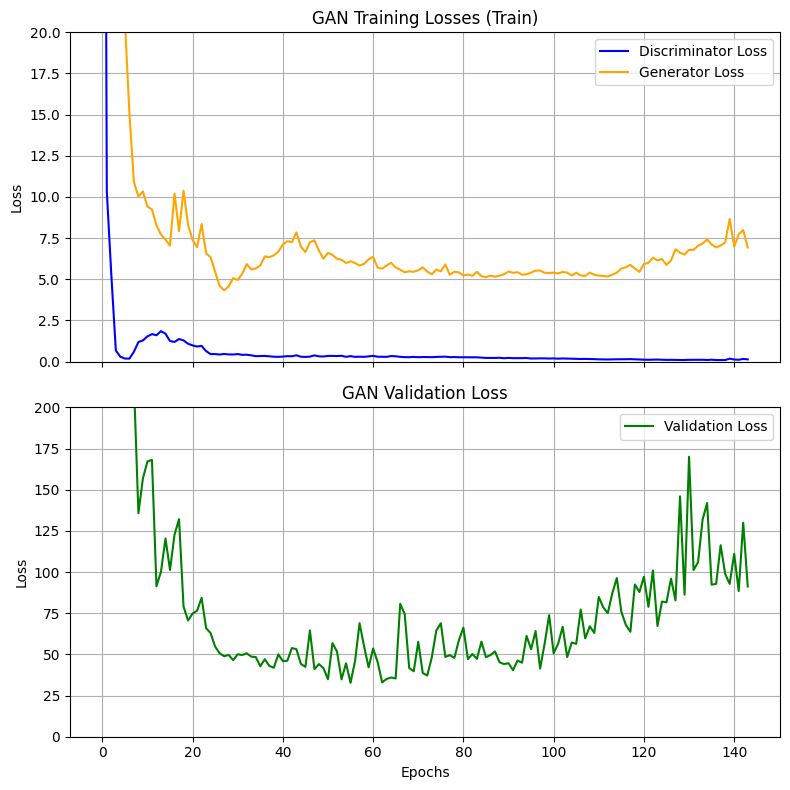

In [ ]:
d_loss, g_loss = np.array(outcomes).T

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(8, 8), sharex=True)
ax1, ax2 = axes
ax1.plot(d_loss, label="Discriminator Loss", color='blue')
ax1.plot(g_loss, label="Generator Loss", color='orange')
ax1.set_ylim(0, 20)
ax1.set_ylabel("Loss")
ax1.set_title("GAN Training Losses (Train)")
ax1.legend()
ax1.grid(True)

ax2.plot(val_loss, label="Validation Loss", color='green')
ax2.set_ylim(0, 200)
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Loss")
ax2.set_title("GAN Validation Loss")
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()

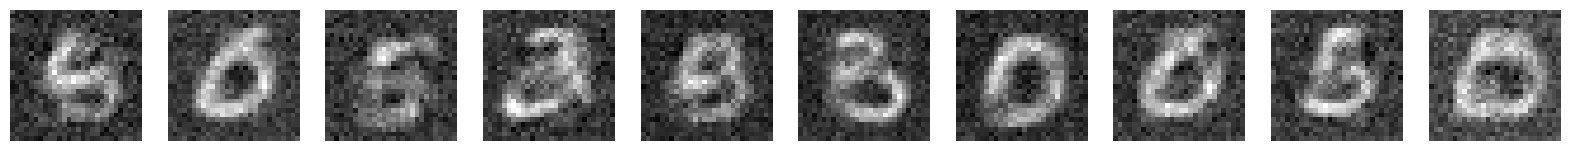

In [20]:
N_SAMPLES = 10
generated_data = trainer.generate(N_SAMPLES)

def display_images(flat_data_entry):
    img_size = int(np.sqrt(flat_data_entry.shape[0]))
    img = flat_data_entry.reshape((img_size, img_size))
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.show()

fig, ax = plt.subplots(1, N_SAMPLES, figsize=(N_SAMPLES*2, 2))
for i in range(N_SAMPLES):
    img_size = int(np.sqrt(generated_data.shape[1]))
    img = generated_data[i].reshape((img_size, img_size))
    ax[i].imshow(img, cmap='gray')
    ax[i].axis('off')